In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5\final(works)")

## Section 1 : Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

In [5]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

In [6]:
SCALED_MODELS = {'Logistic Regression', 'KNN', 'SVC', 'Naive Bayes'}

MODEL_COLORS = {
    'Logistic Regression':'#3498DB', 'Naive Bayes':'#1ABC9C',
    'KNN':'#F39C12',                 'Decision Tree':'#E67E22',
    'Random Forest':'#2ECC71',       'Extra Trees':'#27AE60',
    'AdaBoost':'#E74C3C',            'Gradient Boosting':'#C0392B',
    'XGBoost':'#8E44AD',             'SVC':'#2C3E50',
}

MODEL_FILES = {
    'Logistic Regression': 'models/logistic_regression.pkl',
    'Naive Bayes':         'models/naive_bayes.pkl',
    'KNN':                 'models/knn.pkl',
    'Decision Tree':       'models/decision_tree.pkl',
    'Random Forest':       'models/random_forest.pkl',
    'Extra Trees':         'models/extra_trees.pkl',
    'AdaBoost':            'models/adaboost.pkl',
    'Gradient Boosting':   'models/gradient_boosting.pkl',
    'XGBoost':             'models/xgboost.pkl',
    'SVC':                 'models/svc.pkl',
}

In [7]:
def get_X(name, X_scaled, X_raw):
    return X_scaled if name in SCALED_MODELS else X_raw

def compute_metrics(models, X_scaled, X_raw, y_test):
    rows = []
    for name, model in models.items():
        X = get_X(name, X_scaled, X_raw)
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        rows.append({
            'Model':     name,
            'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
            'F1 Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
            'ROC-AUC':   round(auc(fpr, tpr), 4),
        })
    return pd.DataFrame(rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)

In [8]:
def plot_cm(y_true, y_pred, title, ax):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:,None]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'],
                linewidths=1, linecolor='white', cbar=False)
    for r in range(2):
        for c in range(2):
            ax.text(c+0.5, r+0.72, f'({cm_pct[r,c]*100:.1f}%)',
                    ha='center', fontsize=7.5, color='dimgray')
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    ax.set_title(f'{title}\nAcc={acc:.3f} F1={f1:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

print('Helper functions ready.')
print(f'Models to evaluate: {len(MODEL_FILES)}')

Helper functions ready.
Models to evaluate: 10


## Section 2 : Load  Model Datatset

In [10]:
models        = {name: joblib.load(path) for name, path in MODEL_FILES.items()}
scaler        = joblib.load('models/scaler.pkl')
feature_names = joblib.load('models/feature_names.pkl')
X_test        = np.load('models/X_test.npy', allow_pickle = True)
X_test_scaled = np.load('models/X_test_scaled.npy', allow_pickle = True)
y_test        = np.load('models/y_test.npy', allow_pickle = True)

print(f'Models loaded: {len(models)}')
print(f'Test samples:  {len(y_test)}')
print(f'Features:      {len(feature_names)}')
print(f'Positive rate: {y_test.mean()*100:.1f}%')

Models loaded: 10
Test samples:  392
Features:      19
Positive rate: 50.0%


## Section 3 : Validation Integrity Check

In [12]:
print('=' * 60)
print('  VALIDATION INTEGRITY CHECK')
print('=' * 60)
print(f'  Test samples         : {len(y_test)}')
print(f'  Positive class (%)   : {y_test.mean()*100:.1f}%')
print(f'  Features             : {X_test.shape[1]}')
print(f'  NaN in X_test        : {pd.DataFrame(X_test).isnull().sum().sum()}')
print(f'  NaN in X_test_scaled : {np.isnan(X_test_scaled).sum()}')
print(f'  Scaler fitted on     : Training set only')
print(f'  Baseline trained before GridSearchCV : Yes')
print(f'  Test set first used  : Now — in this notebook only')
print('\n  Integrity check passed.')

  VALIDATION INTEGRITY CHECK
  Test samples         : 392
  Positive class (%)   : 50.0%
  Features             : 19
  NaN in X_test        : 0
  NaN in X_test_scaled : 0
  Scaler fitted on     : Training set only
  Baseline trained before GridSearchCV : Yes
  Test set first used  : Now — in this notebook only

  Integrity check passed.


## Section 4 Full Metrics Table

In [13]:
metrics_df = compute_metrics(models, X_test_scaled, X_test, y_test)
print('=== Test Set Evaluation — All 9 Models ===')
display(metrics_df.style
        .highlight_max(subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'], color='#d4edda')
        .highlight_min(subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'], color='#fde8e8')
        .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC']))

=== Test Set Evaluation — All 9 Models ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8852,1.0000,0.7704,0.8703,0.8838
1,XGBoost,0.8852,1.0000,0.7704,0.8703,0.8762
2,AdaBoost,0.8776,1.0000,0.7551,0.8605,0.8851
3,Decision Tree,0.8724,0.9679,0.7704,0.8580,0.8628
4,Random Forest,0.8444,0.9787,0.7041,0.8190,0.8789
5,Logistic Regression,0.8291,0.9708,0.6786,0.7988,0.8767
6,Extra Trees,0.8265,0.9776,0.6684,0.7939,0.8794
7,SVC,0.8240,1.0000,0.6480,0.7864,0.8790
8,Naive Bayes,0.8214,1.0000,0.6429,0.7826,0.8688
9,KNN,0.7806,0.9167,0.6173,0.7378,0.8205


In [14]:
# Full classification reports
for name, model in models.items():
    X = get_X(name, X_test_scaled, X_test)
    y_pred = model.predict(X)
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(classification_report(y_test, y_pred,
                                target_names=['No Osteoporosis','Osteoporosis']))


  Logistic Regression
                 precision    recall  f1-score   support

No Osteoporosis       0.75      0.98      0.85       196
   Osteoporosis       0.97      0.68      0.80       196

       accuracy                           0.83       392
      macro avg       0.86      0.83      0.83       392
   weighted avg       0.86      0.83      0.83       392


  Naive Bayes
                 precision    recall  f1-score   support

No Osteoporosis       0.74      1.00      0.85       196
   Osteoporosis       1.00      0.64      0.78       196

       accuracy                           0.82       392
      macro avg       0.87      0.82      0.82       392
   weighted avg       0.87      0.82      0.82       392


  KNN
                 precision    recall  f1-score   support

No Osteoporosis       0.71      0.94      0.81       196
   Osteoporosis       0.92      0.62      0.74       196

       accuracy                           0.78       392
      macro avg       0.81      0.7

## Section 5 : Confusion matrix - All models

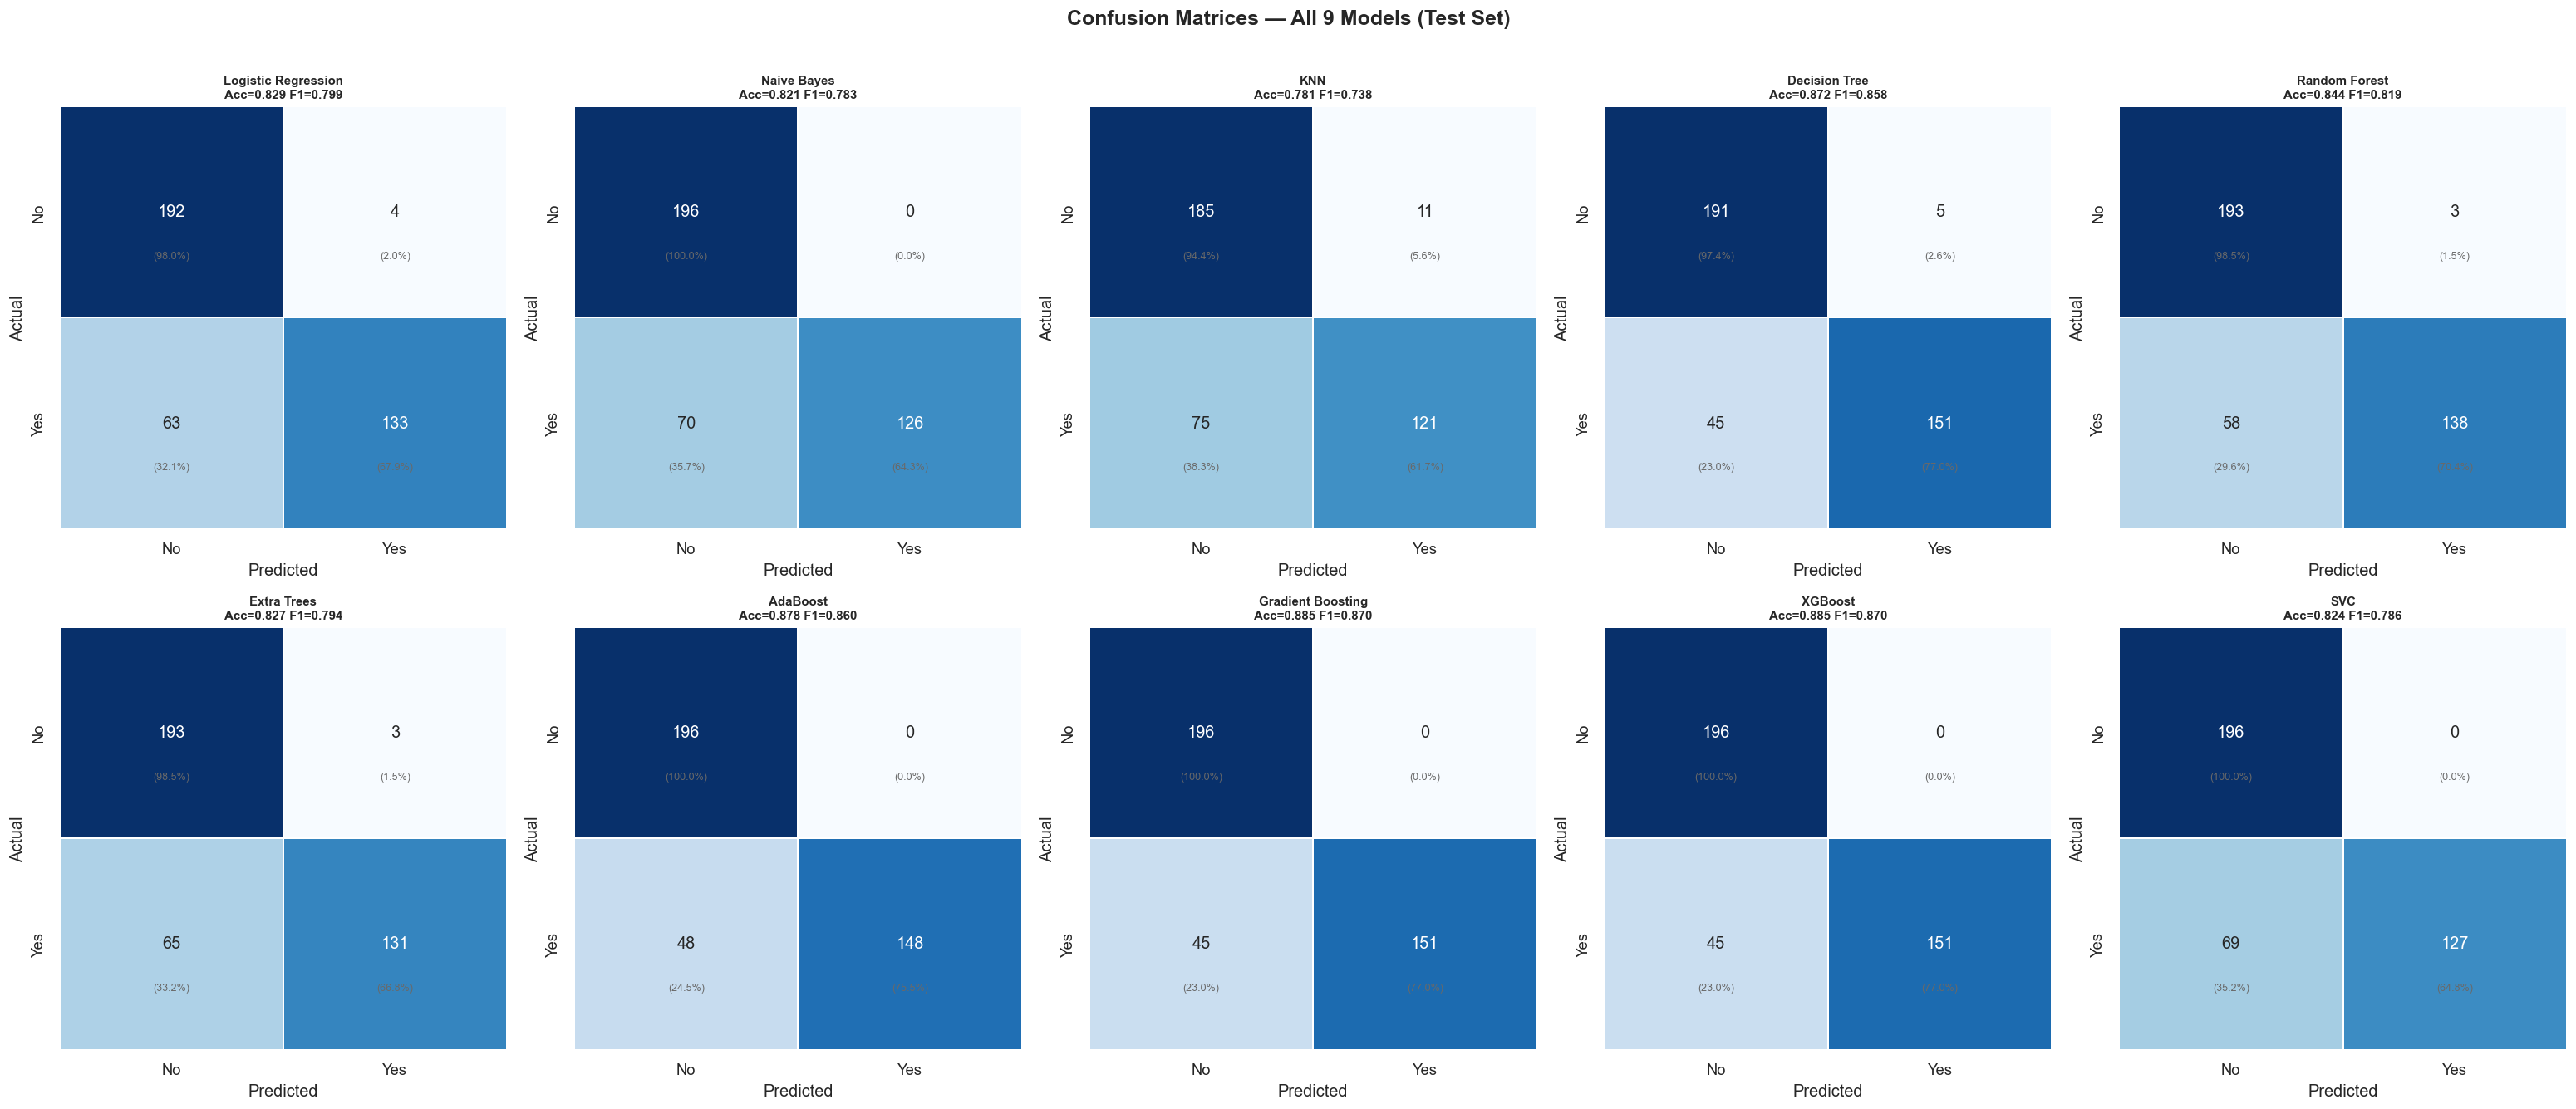

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(26, 11))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    X = get_X(name, X_test_scaled, X_test)
    plot_cm(y_test, model.predict(X), name, axes[i])

# Hide unused subplot
for j in range(len(models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All 9 Models (Test Set)', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plots/6_Confusion_matrix_9.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 6 : ROC _ AUC

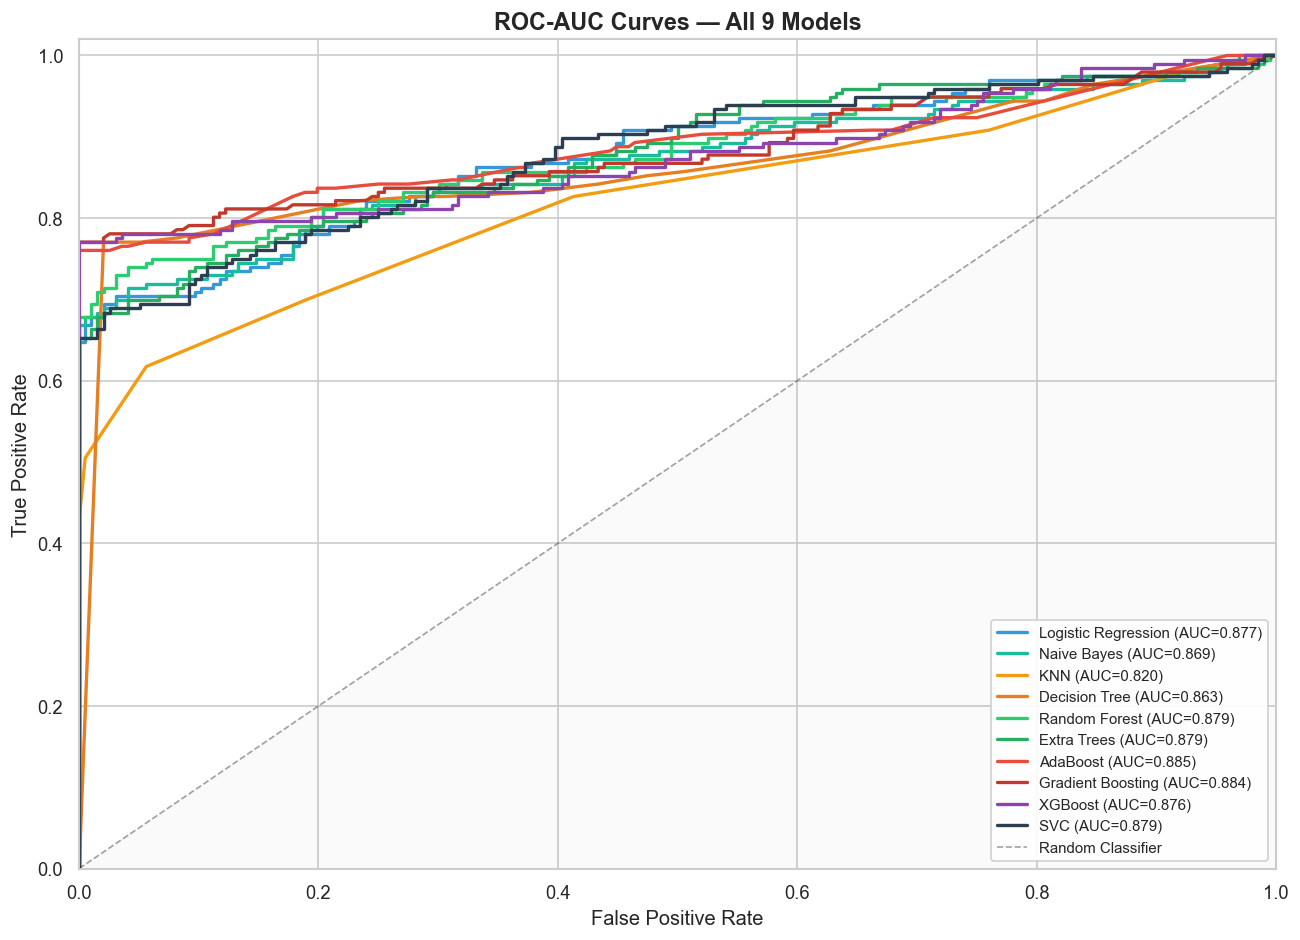

In [16]:
fig, ax = plt.subplots(figsize=(11, 8))

for name, model in models.items():
    X = get_X(name, X_test_scaled, X_test)
    y_prob = model.predict_proba(X)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=MODEL_COLORS[name],
            label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curves — All 9 Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.savefig('plots/7_Roc_AUC.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 7 : Recall Curves

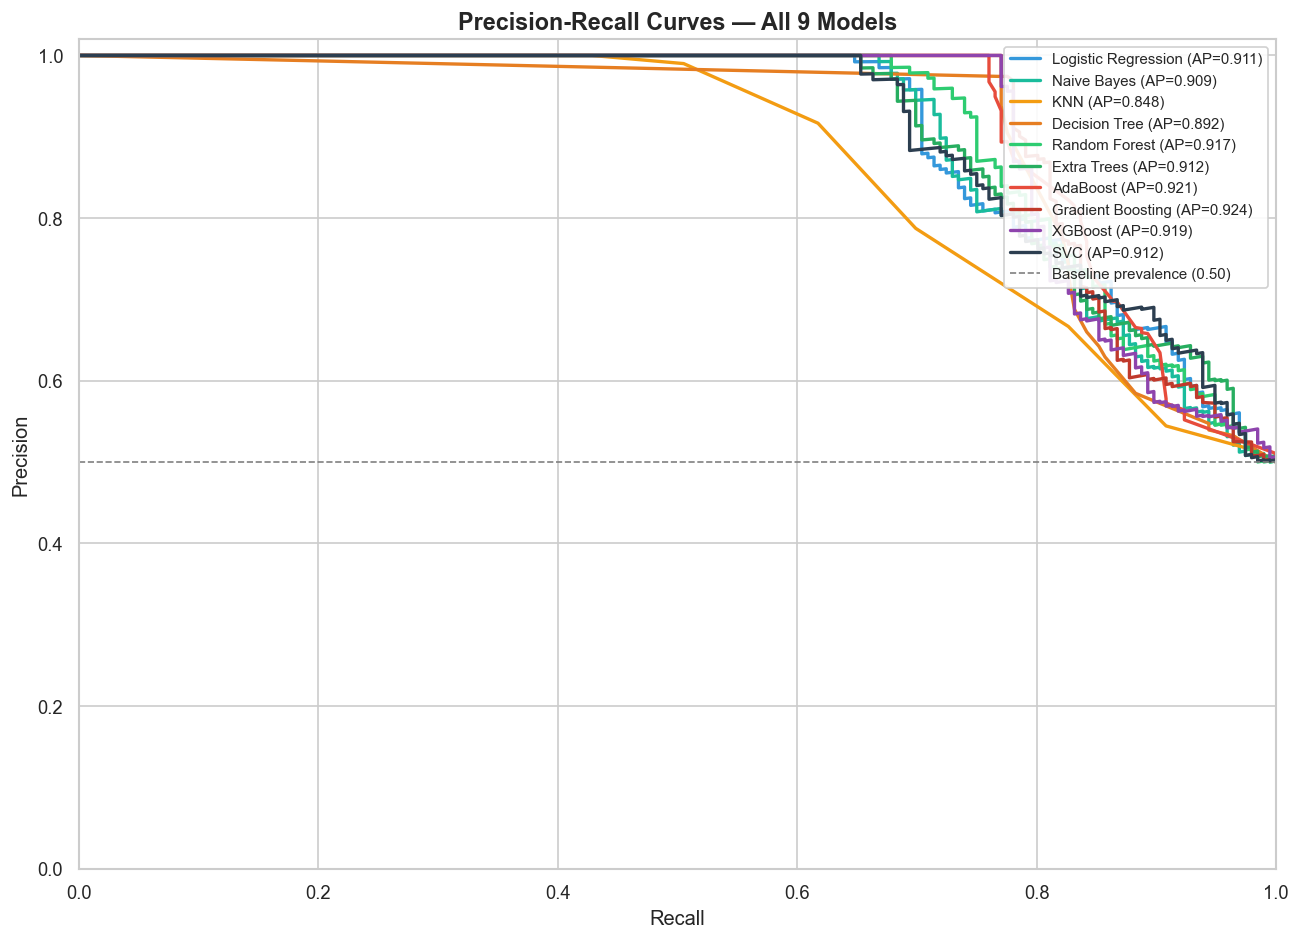

In [18]:
fig, ax = plt.subplots(figsize=(11, 8))
baseline_prev = y_test.mean()

for name, model in models.items():
    X = get_X(name, X_test_scaled, X_test)
    y_prob = model.predict_proba(X)[:,1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, linewidth=2, color=MODEL_COLORS[name],
            label=f'{name} (AP={ap:.3f})')

ax.axhline(baseline_prev, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline prevalence ({baseline_prev:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All 9 Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.savefig('plots/8_Recall_curves.png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()

## Section 8 : Comparitive dashboard

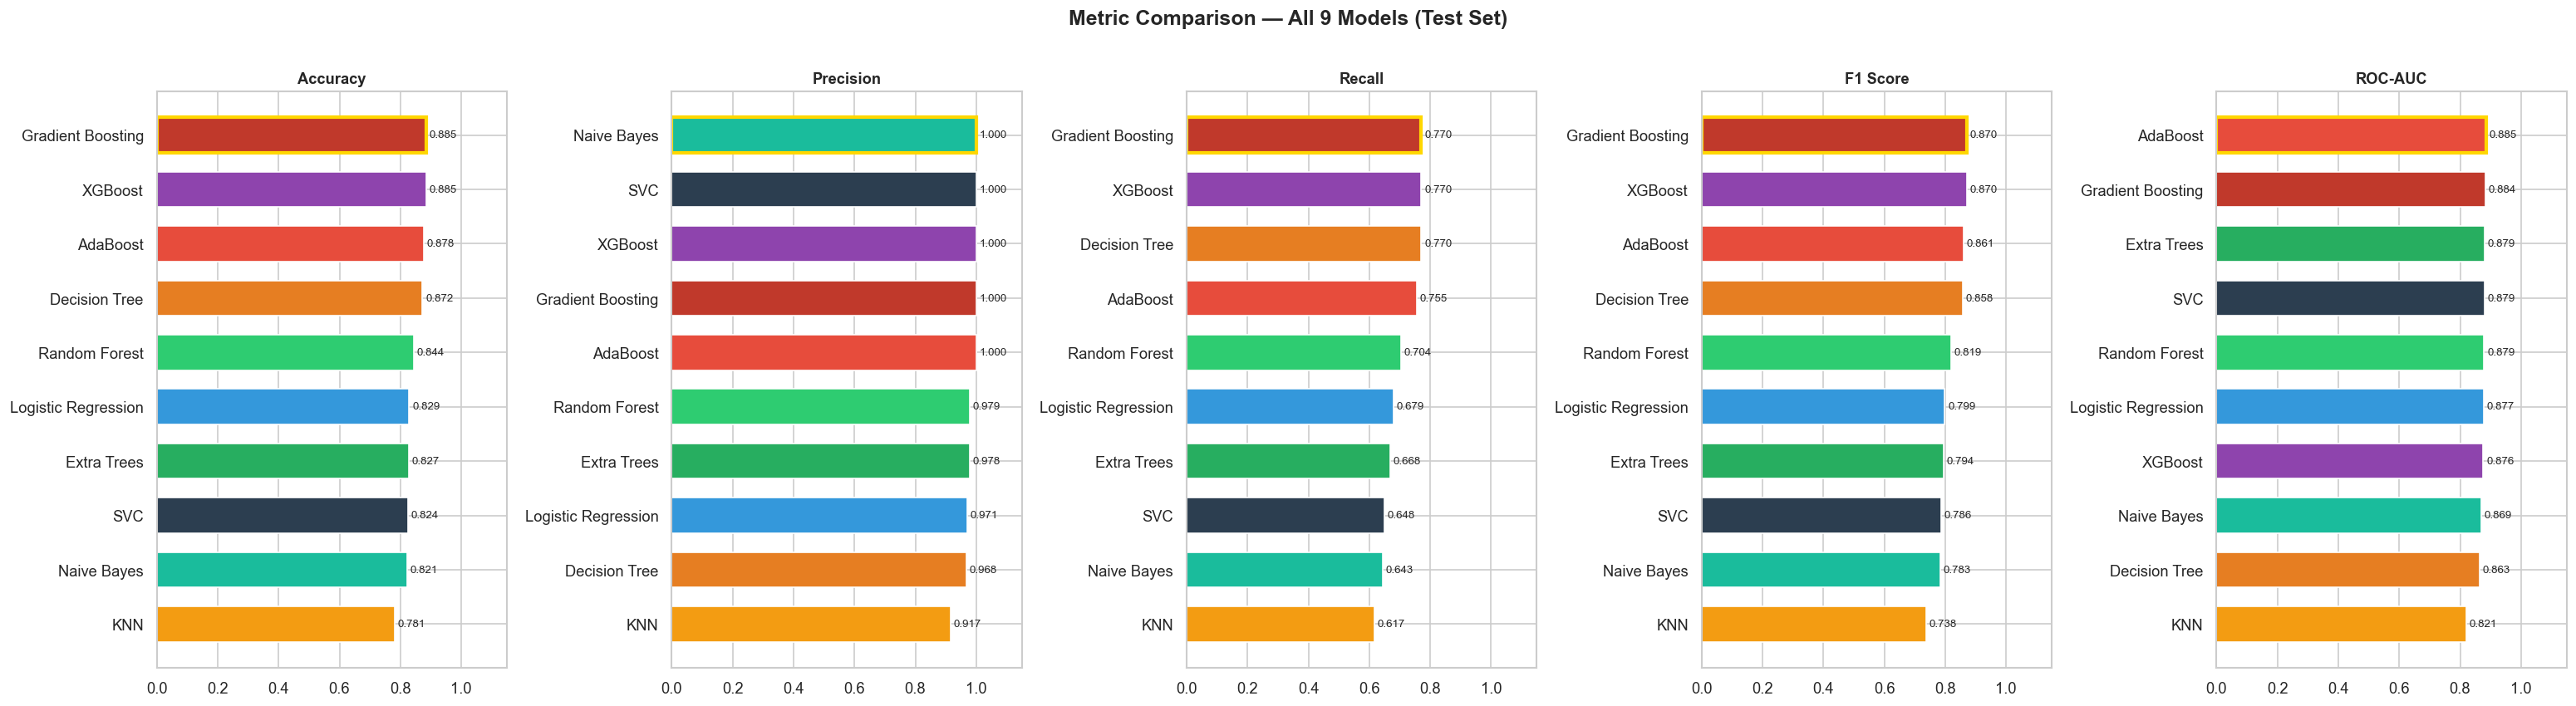

In [19]:
metric_cols = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
fig, axes   = plt.subplots(1, 5, figsize=(26, 7))

for i, metric in enumerate(metric_cols):
    df_s   = metrics_df.sort_values(metric, ascending=True)
    colors = [MODEL_COLORS.get(m,'gray') for m in df_s['Model']]
    bars   = axes[i].barh(df_s['Model'], df_s[metric], color=colors,
                          edgecolor='white', height=0.65)
    bars[-1].set_edgecolor('gold'); bars[-1].set_linewidth(2.5)
    axes[i].set_title(metric, fontsize=11, fontweight='bold')
    axes[i].set_xlim(0, 1.15)
    for bar in bars:
        axes[i].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                     f'{bar.get_width():.3f}', va='center', fontsize=8)

plt.suptitle('Metric Comparison — All 9 Models (Test Set)', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plots/9_Metric_comparison.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

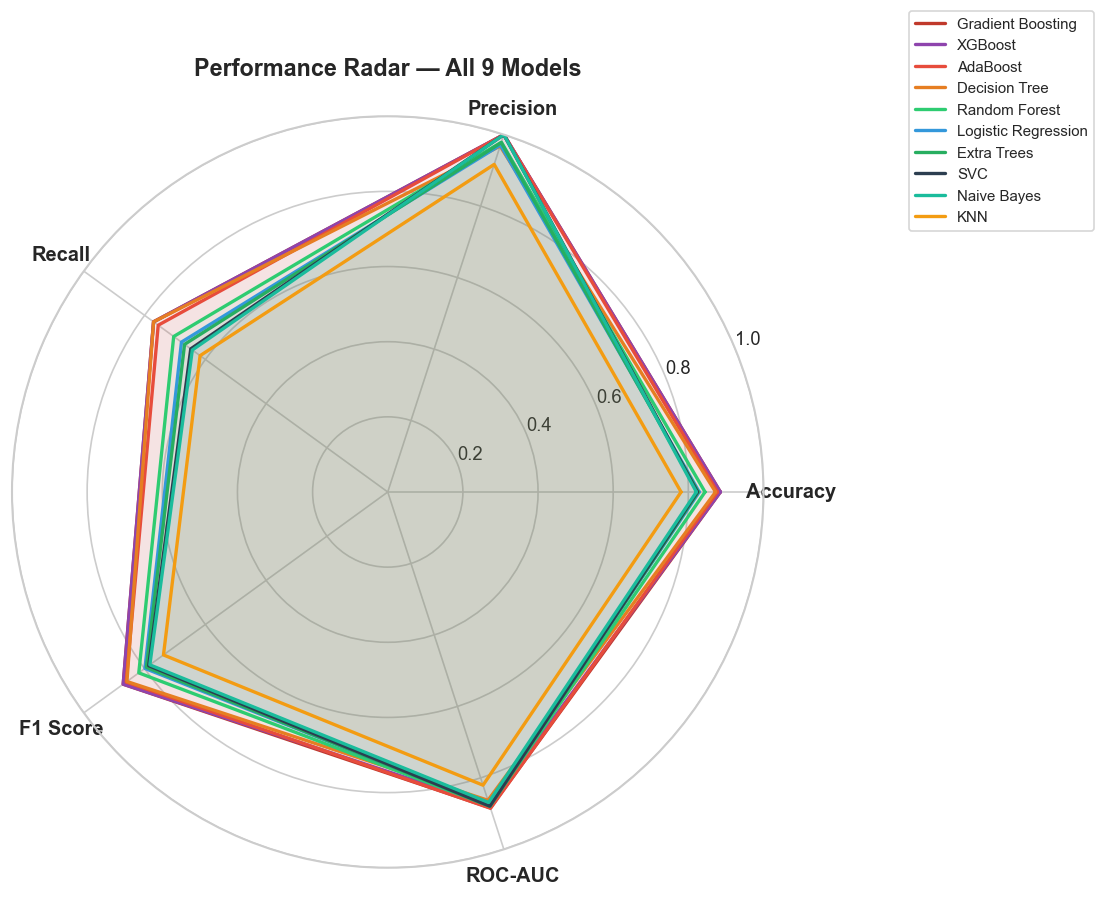

In [20]:
# Radar chart — all 9 models
N      = len(metric_cols)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for _, row in metrics_df.iterrows():
    vals  = row[metric_cols].tolist() + [row[metric_cols[0]]]
    color = MODEL_COLORS.get(row['Model'],'gray')
    ax.plot(angles, vals, linewidth=2, color=color, label=row['Model'])
    ax.fill(angles, vals, alpha=0.04, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_cols, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Performance Radar — All 9 Models', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.savefig('plots/10_Radar_chart.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 9 : Three way comparison : Baseline VS Tuned CV vs Test F1

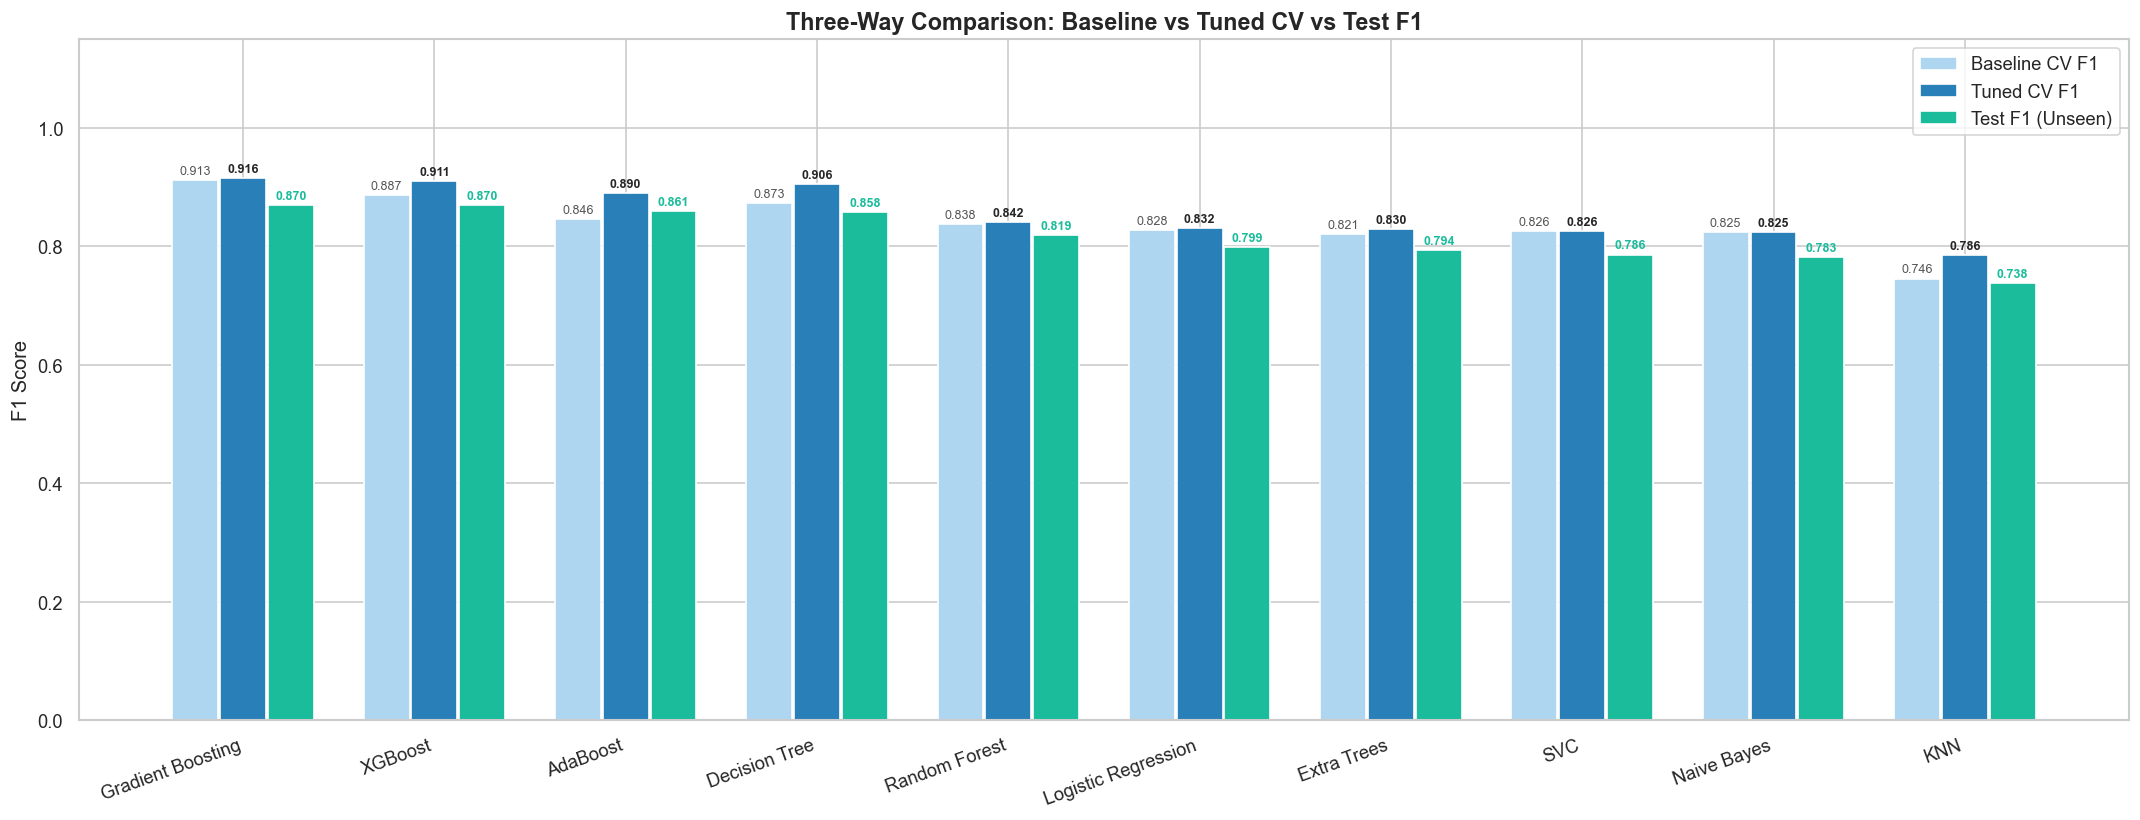

Key: Large gap between Tuned CV F1 and Test F1 may indicate overfitting to CV folds.


In [22]:
try:
    baseline_df = pd.read_csv('models/baseline_results.csv')
    tuned_df    = pd.read_csv('models/tuned_results.csv')

    model_names = metrics_df['Model'].tolist()
    base_f1  = [baseline_df[baseline_df['Model']==m]['CV F1 Mean'].values[0]
                if len(baseline_df[baseline_df['Model']==m])>0 else 0 for m in model_names]
    tuned_f1 = [tuned_df[tuned_df['Model']==m]['CV F1 Mean'].values[0]
                if len(tuned_df[tuned_df['Model']==m])>0 else 0 for m in model_names]
    test_f1  = metrics_df['F1 Score'].tolist()

    x = np.arange(len(model_names))
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.bar(x-0.25, base_f1,  width=0.24, label='Baseline CV F1',  color='#AED6F1', edgecolor='white')
    ax.bar(x+0.00, tuned_f1, width=0.24, label='Tuned CV F1',     color='#2980B9', edgecolor='white')
    ax.bar(x+0.25, test_f1,  width=0.24, label='Test F1 (Unseen)',color='#1ABC9C', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right')
    ax.set_ylim(0, 1.15)
    ax.set_title('Three-Way Comparison: Baseline vs Tuned CV vs Test F1', fontsize=14, fontweight='bold')
    ax.set_ylabel('F1 Score'); ax.legend(fontsize=11)
    for i, (b,t,ts) in enumerate(zip(base_f1, tuned_f1, test_f1)):
        ax.text(i-0.25, b+0.01, f'{b:.3f}', ha='center', fontsize=7.5, color='#555')
        ax.text(i+0.00, t+0.01, f'{t:.3f}', ha='center', fontsize=7.5, fontweight='bold')
        ax.text(i+0.25, ts+0.01,f'{ts:.3f}',ha='center', fontsize=7.5, color='#1ABC9C', fontweight='bold')
    plt.savefig('plots/11_3_way_comparison.png', bbox_inches='tight')
    plt.tight_layout() 
    plt.show()
    print('Key: Large gap between Tuned CV F1 and Test F1 may indicate overfitting to CV folds.')
except Exception as e:
    print(f'Could not load baseline/tuned results: {e}')
    print('Run NB2 first to generate these files.')